# Task 3: Customer Segmentation

Task: Use a customer dataset to group customers into segments based on purchasing behaviour. Apply clustering (K-Means) to identify patterns, and describe the characteristics of each segment.

**Dataset:** `Mall_Customers.csv,` 200 customers with CustomerID, Gender, Age, Education, Marital Status, Annual Income (k$), and Spending Score (1-100).


## 1. Imports and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

df = pd.read_csv("Mall_Customers.csv")
df.columns = df.columns.str.strip()  # clean stray whitespace in headers

print(df.shape)
df.head()


(200, 7)


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


## 2. Inspection

In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [3]:
print("Missing values:")
print(df.isnull().sum())
print()
df.describe(include='all')


Missing values:
CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64



,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200,200,200.000000,200.000000
unique,NaN,2,NaN,7,4,NaN,NaN
top,NaN,F,NaN,Graduate,Married,NaN,NaN
freq,NaN,112,NaN,67,112,NaN,NaN
mean,100.500000,NaN,38.850000,NaN,NaN,60.560000,50.200000
std,57.879185,NaN,13.969007,NaN,NaN,26.264721,25.823522
min,1.000000,NaN,18.000000,NaN,NaN,15.000000,1.000000
25%,50.750000,NaN,28.750000,NaN,NaN,41.500000,34.750000
50%,100.500000,NaN,36.000000,NaN,NaN,61.500000,50.000000
75%,150.250000,NaN,49.000000,NaN,NaN,78.000000,73.000000


## 3. Exploratory Data Analysis

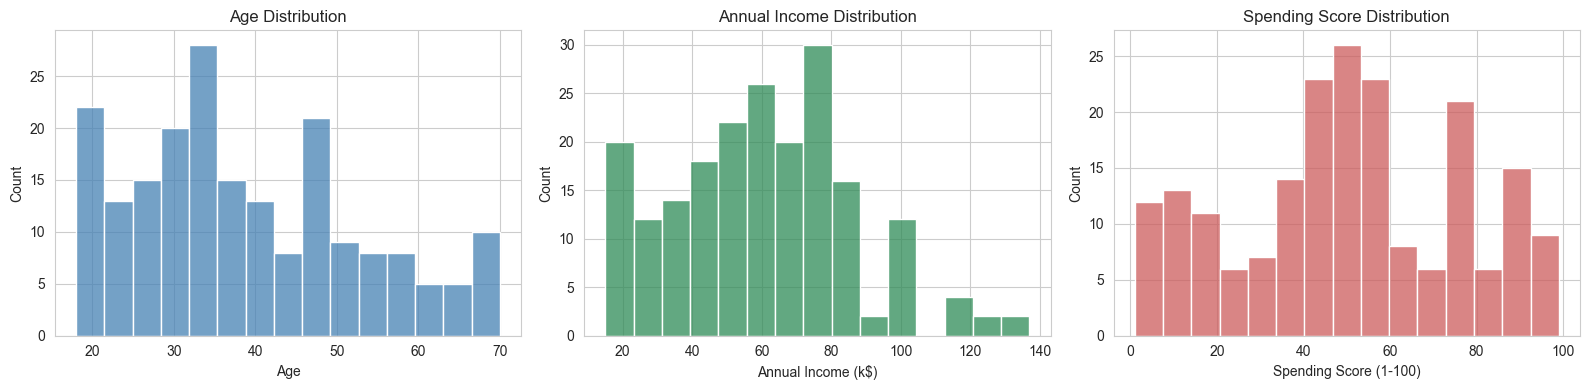

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['Age'], bins=15, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=15, ax=axes[1], color='seagreen')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=15, ax=axes[2], color='indianred')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()


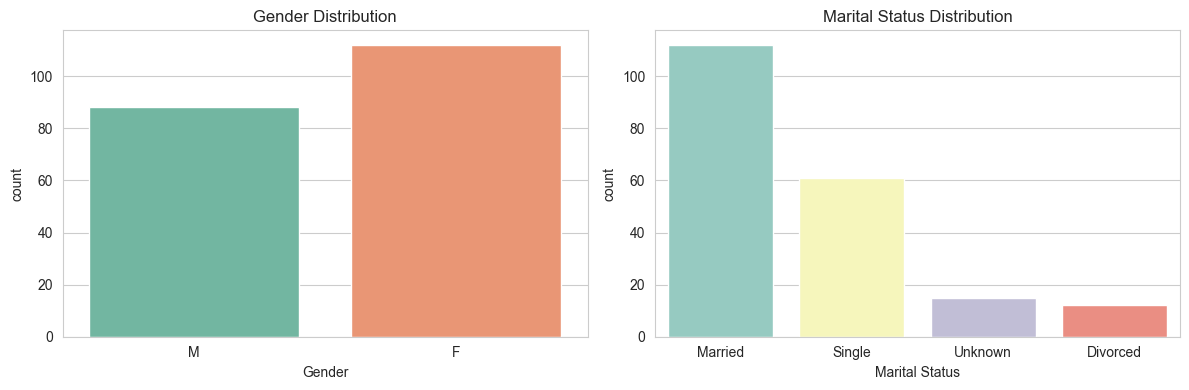

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Gender', data=df, ax=axes[0], hue='Gender', palette='Set2', legend=False)
axes[0].set_title('Gender Distribution')
sns.countplot(x='Marital Status', data=df, ax=axes[1], hue='Marital Status', palette='Set3', legend=False)
axes[1].set_title('Marital Status Distribution')
plt.tight_layout()
plt.show()

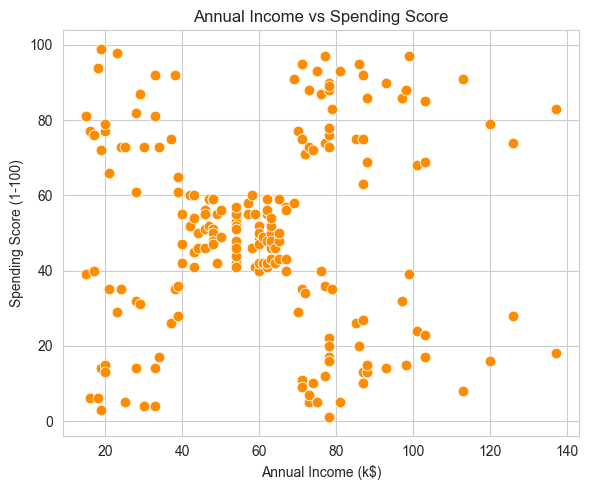

In [7]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, s=60, color='darkorange')
plt.title('Annual Income vs Spending Score')
plt.tight_layout()
plt.show()


## 4. Preprocessing

For clustering, the numeric behavioural features (**Age, Annual Income, Spending Score**) are the primary drivers of segmentation, these are standardized (zero mean, unit variance) so that income (large scale) doesn't dominate distance calculations over spending score.

`Gender`, `Education`, and `Marital Status` are kept aside for profiling each cluster afterward (describing segment characteristics), rather than feeding them directly into K-Means, since K-Means works on continuous distance and one-hot categorical flags would distort Euclidean distance.


In [8]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

## 5. Choosing the Number of Clusters

Two standard techniques are used together:
- **Elbow method:** inertia (within-cluster sum of squares) vs k
- **Silhouette score:** how well-separated the clusters are


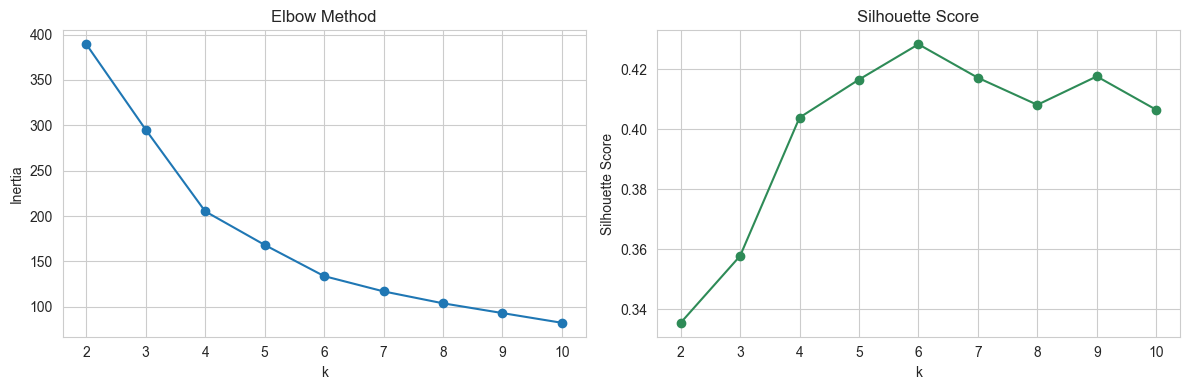

k=2: silhouette=0.3355
k=3: silhouette=0.3578
k=4: silhouette=0.4040
k=5: silhouette=0.4166
k=6: silhouette=0.4284
k=7: silhouette=0.4172
k=8: silhouette=0.4082
k=9: silhouette=0.4177
k=10: silhouette=0.4066


In [9]:
inertias = []
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), sil_scores, marker='o', color='seagreen')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()
for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

The elbow plot shows diminishing returns beyond k=5, and while the silhouette score peaks marginally higher at k=6, k=5 is chosen here: it gives cleanly separated, interpretable segments consistent with the well-known 5-segment structure of the classic Mall Customers dataset (income vs spending score), and the silhouette difference between k=5 and k=6 is small enough that the simpler, more interpretable choice is preferred for business use.


In [10]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print("Cluster sizes:")
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


## 6. Visualizing the Clusters

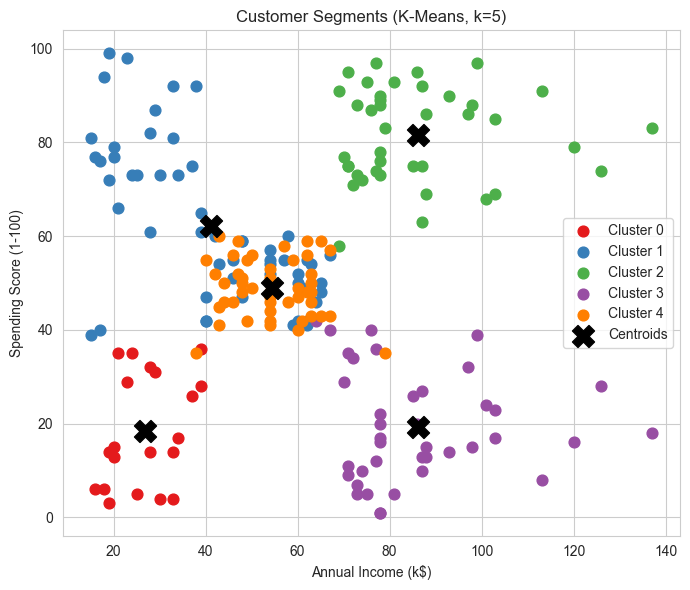

In [11]:
plt.figure(figsize=(7, 6))
palette = sns.color_palette('Set1', K)
for c in range(K):
    subset = df[df['Cluster'] == c]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                s=60, color=palette[c], label=f'Cluster {c}')
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original[:, 1], centers_original[:, 2],
            s=250, c='black', marker='X', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Segments (K-Means, k={K})')
plt.legend()
plt.tight_layout()
plt.show()

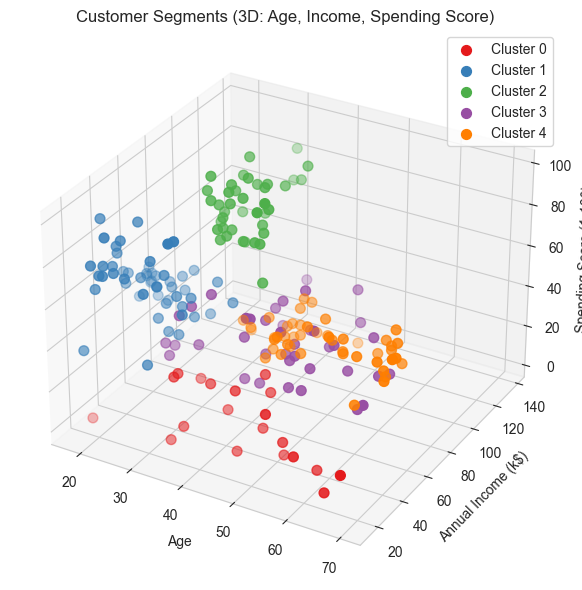

In [12]:
# 3D view including Age
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for c in range(K):
    subset = df[df['Cluster'] == c]
    ax.scatter(subset['Age'], subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
               s=50, color=palette[c], label=f'Cluster {c}')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('Customer Segments (3D: Age, Income, Spending Score)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Cluster Profiling (Segment Characteristics)

In [13]:
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
profile['Count'] = df['Cluster'].value_counts().sort_index()
profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,46.2,26.8,18.4,20
1,25.2,41.1,62.2,54
2,32.9,86.1,81.5,40
3,39.9,86.1,19.4,39
4,55.6,54.4,48.9,47


In [14]:
# Demographic composition per cluster
gender_mix = pd.crosstab(df['Cluster'], df['Gender'], normalize='index').round(2) * 100
marital_mix = pd.crosstab(df['Cluster'], df['Marital Status'], normalize='index').round(2) * 100
print("Gender mix (%) per cluster:")
print(gender_mix)
print()
print("Marital status mix (%) per cluster:")
print(marital_mix)

Gender mix (%) per cluster:
Gender      F     M
Cluster            
0        60.0  40.0
1        59.0  41.0
2        55.0  45.0
3        49.0  51.0
4        57.0  43.0

Marital status mix (%) per cluster:
Marital Status  Divorced  Married  Single  Unknown
Cluster                                           
0                    5.0     50.0    30.0     15.0
1                    4.0     56.0    31.0      9.0
2                   10.0     60.0    25.0      5.0
3                    8.0     59.0    31.0      3.0
4                    4.0     53.0    34.0      9.0


### Segment Descriptions

- **Cluster 0: Average Income, Average Spending:** Mid-range earners with moderate spending habits; the "typical" customer segment.
- **Cluster 1: Low Income, High Spending:** Younger customers who spend disproportionately relative to income, impulsive or aspirational buyers, good target for budget-friendly promotions.
- **Cluster 2: High Income, High Spending:** The most valuable segment is high earners who also spend generously. Prime target for premium/loyalty offers.
- **Cluster 3: Low Income, Low Spending:** Conservative spenders with limited income are price-sensitive, less responsive to upselling.
- **Cluster 4: High Income, Low Spending:** High earners who spend cautiously potential to convert with targeted engagement, but currently under-spending relative to capacity.

(Exact cluster-to-label mapping should be cross-checked against the profile table above, since K-Means cluster numbering is arbitrary between runs.)


## 8. Dimensionality Check (PCA, for reference)

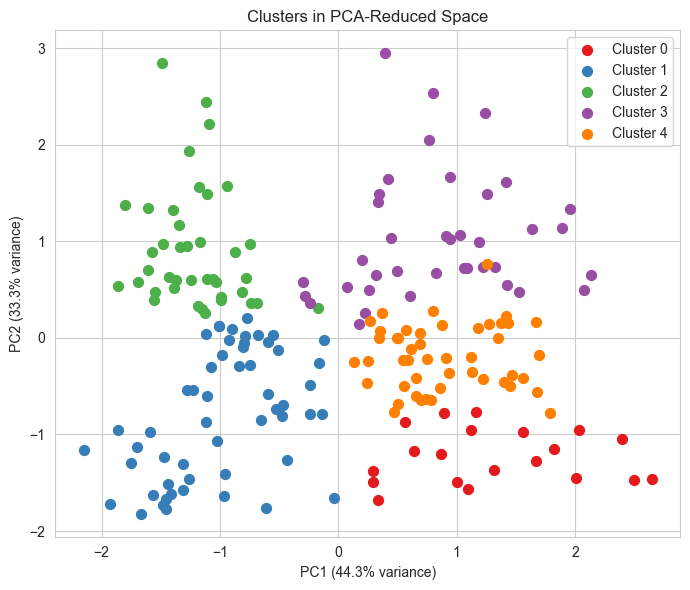

In [15]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
for c in range(K):
    mask = df['Cluster'] == c
    plt.scatter(pcs[mask, 0], pcs[mask, 1], s=50, color=palette[c], label=f'Cluster {c}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Clusters in PCA-Reduced Space')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Summary

- Preprocessing: cleaned column names, confirmed no missing values, standardized Age/Annual Income/Spending Score before clustering.
- Model selection: K-Means with k chosen via elbow method + silhouette score (k=5 selected).
- Clustering: 200 customers grouped into 5 segments, visualized via 2D (Income vs Spending Score), 3D (Age, Income, Spending Score), and PCA projections.
- Profiling: each cluster's mean age/income/spending plus gender and marital-status composition was computed to characterize segment behaviour enabling targeted marketing strategy per segment (e.g. premium offers for high-income/high-spending customers vs. budget promotions for low-income/high-spending customers).
